Load saved models and test on sample dataset.

Requires following notebooks to be run first:
- create_dataset.ipynb
- save_models.ipynb

In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.mixture import GaussianMixture

In [2]:
def preprocess_image(image):
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return preprocess(image)

def extract_features(model, input_tensor):
    model.eval()
    with torch.no_grad():
        features = model(input_tensor)
    return features

In [3]:
# load frames
frames_path = "dataset/frames/"
frames = os.listdir(frames_path)

In [4]:
def load_img(img_path, target_size=None):
    """Load and resize an image."""
    img = Image.open(img_path)
    if target_size:
        img = img.resize(target_size)
    return np.array(img)  # Convert to a numpy array for matplotlib

def visualize_embeddings(embeddings):
    # Create a scatter plot
    plt.figure(figsize=(10, 8))

    # Loop through each point and add the corresponding thumbnail
    for idx, point in enumerate(embeddings):
        x, y = point[0], point[1]
        
        plt.scatter(x, y, alpha=0)  # Hide the original points
        
        # Load and create thumbnail for the image
        img = load_img(os.path.join(frames_path, frames[idx]), target_size=(50, 50))  # Resize thumbnail
        imagebox = OffsetImage(img, zoom=0.8)  # Adjust zoom as needed
        
        # Create an annotation box with the thumbnail
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.1)
        
        # Add the annotation box to the plot
        plt.gca().add_artist(ab)

    plt.title("Image Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.autoscale(True)
    plt.grid()
    plt.show()

Extract embeddings

In [5]:
# ResNet model
model = torch.load("saved_models/ResNet50_decap.pt", map_location='cpu', weights_only=False)

json_data_path = "dataset/json_data/model_resnet.json"
model_json_data = []
embeddings = []

for i, frame in enumerate(frames):
    img = Image.open(frames_path + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    features = extract_features(model, input_tensor)

    data = {
        "filename": f"frame{i}.jpg",
        "feature": features.cpu().numpy().flatten().tolist()
    }
    model_json_data.append(data)

    embeddings.append(features.cpu().numpy().flatten())

with open(json_data_path, 'w') as json_file:
    json.dump(model_json_data, json_file, indent=4)

embeddings = np.array(embeddings)

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embeddings)
# visualize_embeddings(pca_results)

In [7]:
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, perplexity=100, n_iter=1000, random_state=42)
# tsne_result = tsne.fit_transform(embeddings)
# visualize_embeddings(tsne_result)

In [8]:
# from umap import UMAP
# umap_2d = UMAP(n_components=2, n_neighbors=10, min_dist=0.1, metric='euclidean', random_state=42)
# umap_2d_results = umap_2d.fit_transform(embeddings)
# visualize_embeddings(umap_2d_results)

Apply density estimation

In [9]:
# # Kernel Density Estimation
# kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
# kde.fit(pca_results)
# kde_density = kde.score_samples(pca_results)
# plt.hist(kde_density, bins=20, alpha=0.7)
# plt.xlabel("Log-density")
# plt.ylabel("Number of images")
# plt.title("Kernel Density Estimation")
# plt.show()

# # Gaussian Mixture Model
# gmm = GaussianMixture(n_components=3, covariance_type='full')
# gmm.fit(pca_results)
# gmm_density = gmm.score_samples(pca_results)
# plt.hist(gmm_density, bins=20, alpha=0.7)
# plt.xlabel("Log-density")
# plt.ylabel("Number of images")
# plt.title("Guassian Mixture Model")
# plt.show()

# # k-Nearest Neighbor Density
# k = 5
# nbrs = NearestNeighbors(n_neighbors=k).fit(pca_results)
# distances, _ = nbrs.kneighbors(pca_results)
# knn_density = 1 / (np.mean(distances, axis=1) + 1e-6)
# plt.hist(knn_density, bins=20, alpha=0.7)
# plt.xlabel("Log-density")
# plt.ylabel("Number of images")
# plt.title("k-Nearest Neighbor")
# plt.show()

Prune results

3.053465266882267


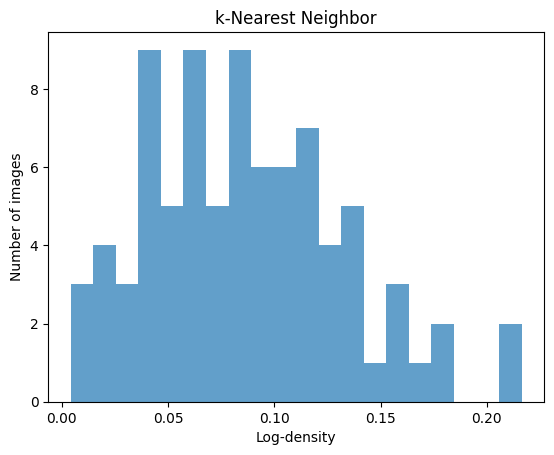

3.1370309444484445


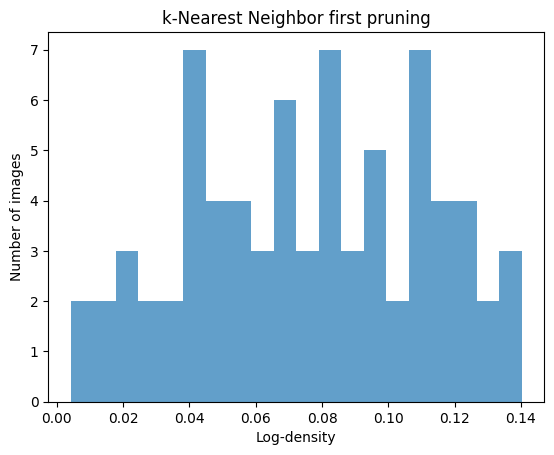

3.1457980436234605


C:\Users\Lars\AppData\Local\Temp\ipykernel_23820\2297880406.py:36: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  second_prune_indices = np.where(first_knn_entropy_pruned <= second_entropy_threshold)[0]


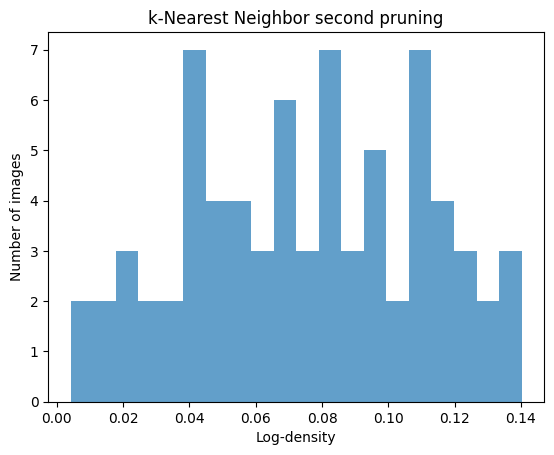

3.2242733166594353


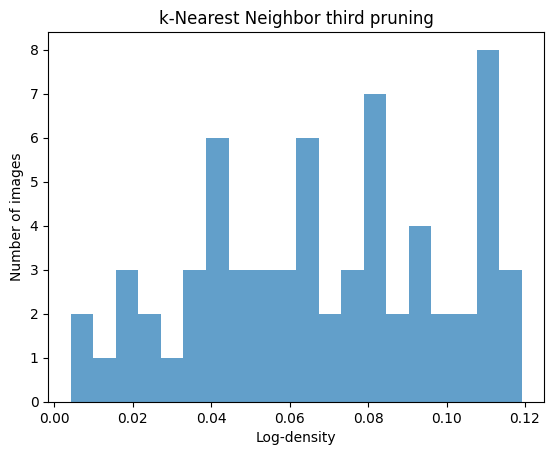

In [ ]:
k = 5 # neighbors
prune = 15 # percentage lowest entropy to be pruned per itteration, lowest entropy = most redundant images

# Full embedding
nbrs = NearestNeighbors(n_neighbors=k).fit(pca_results)
distances, _ = nbrs.kneighbors(pca_results)
knn_entropy = np.log(np.mean(distances))
knn_entropies = np.log(np.mean(distances, axis=1))
print(knn_entropy)

knn_density = 1 / (np.mean(distances, axis=1) + 1e-6)
plt.hist(knn_density, bins=20, alpha=0.7)
plt.xlabel("Log-density")
plt.ylabel("Number of images")
plt.title("k-Nearest Neighbor")
plt.show()

# First pruning
first_entropy_threshold = np.percentile(knn_entropies, prune)
first_prune_indices = np.where(knn_entropies <= first_entropy_threshold)[0]
first_pruned_embedding = np.delete(pca_results, first_prune_indices, axis=0)

first_nbrs = NearestNeighbors(n_neighbors=k).fit(first_pruned_embedding)
first_distances, _ = nbrs.kneighbors(first_pruned_embedding)
first_knn_entropy_pruned = np.log(np.mean(first_distances))
first_knn_entropies_pruned = np.log(np.mean(first_distances, axis=1))
print(first_knn_entropy_pruned)

first_knn_density = 1 / (np.mean(first_distances, axis=1) + 1e-6)
plt.hist(first_knn_density, bins=20, alpha=0.7)
plt.xlabel("Log-density")
plt.ylabel("Number of images")
plt.title("k-Nearest Neighbor first pruning")
plt.show()

# Second pruning
second_entropy_threshold = np.percentile(first_knn_entropy_pruned, prune)
second_prune_indices = np.where(first_knn_entropy_pruned <= second_entropy_threshold)[0]
second_pruned_embedding = np.delete(first_pruned_embedding, second_prune_indices, axis=0)

second_nbrs = NearestNeighbors(n_neighbors=k).fit(second_pruned_embedding)
second_distances, _ = nbrs.kneighbors(second_pruned_embedding)
second_knn_entropy_pruned = np.log(np.mean(second_distances))
second_knn_entropies_pruned = np.log(np.mean(second_distances, axis=1))
print(second_knn_entropy_pruned)

second_knn_density = 1 / (np.mean(second_distances, axis=1) + 1e-6)
plt.hist(second_knn_density, bins=20, alpha=0.7)
plt.xlabel("Log-density")
plt.ylabel("Number of images")
plt.title("k-Nearest Neighbor second pruning")
plt.show()

# Third pruning
third_entropy_threshold = np.percentile(second_knn_entropies_pruned, prune)
third_prune_indices = np.where(second_knn_entropies_pruned <= third_entropy_threshold)[0]
third_pruned_embedding = np.delete(second_pruned_embedding, third_prune_indices, axis=0)

third_nbrs = NearestNeighbors(n_neighbors=k).fit(third_pruned_embedding)
third_distances, _ = nbrs.kneighbors(third_pruned_embedding)
third_knn_entropy_pruned = np.log(np.mean(third_distances))
third_knn_entropies_pruned = np.log(np.mean(third_distances, axis=1))
print(third_knn_entropy_pruned)

third_knn_density = 1 / (np.mean(third_distances, axis=1) + 1e-6)
plt.hist(third_knn_density, bins=20, alpha=0.7)
plt.xlabel("Log-density")
plt.ylabel("Number of images")
plt.title("k-Nearest Neighbor third pruning")
plt.show()

Visualize difference

84


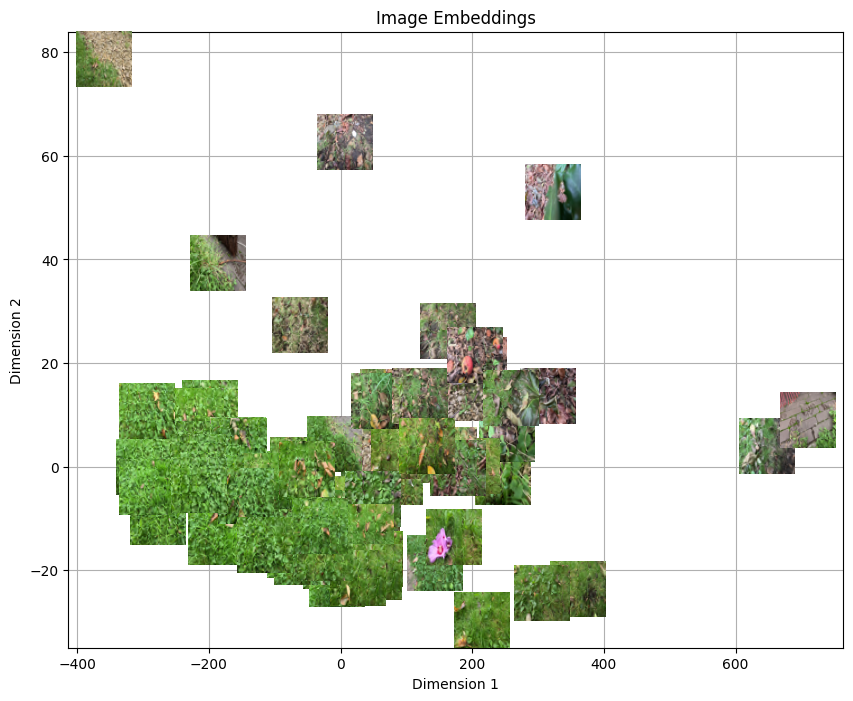

75


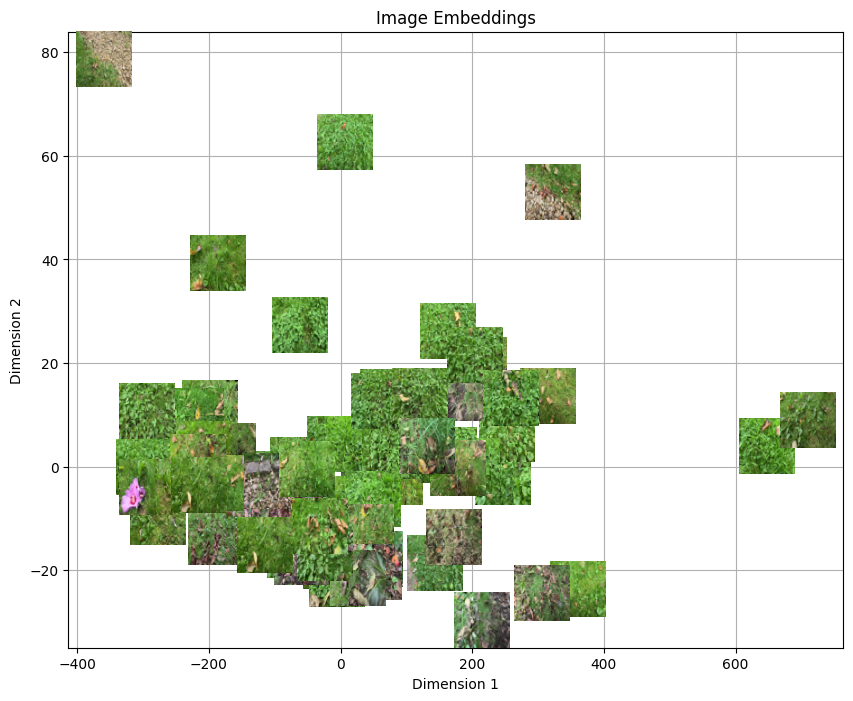

74


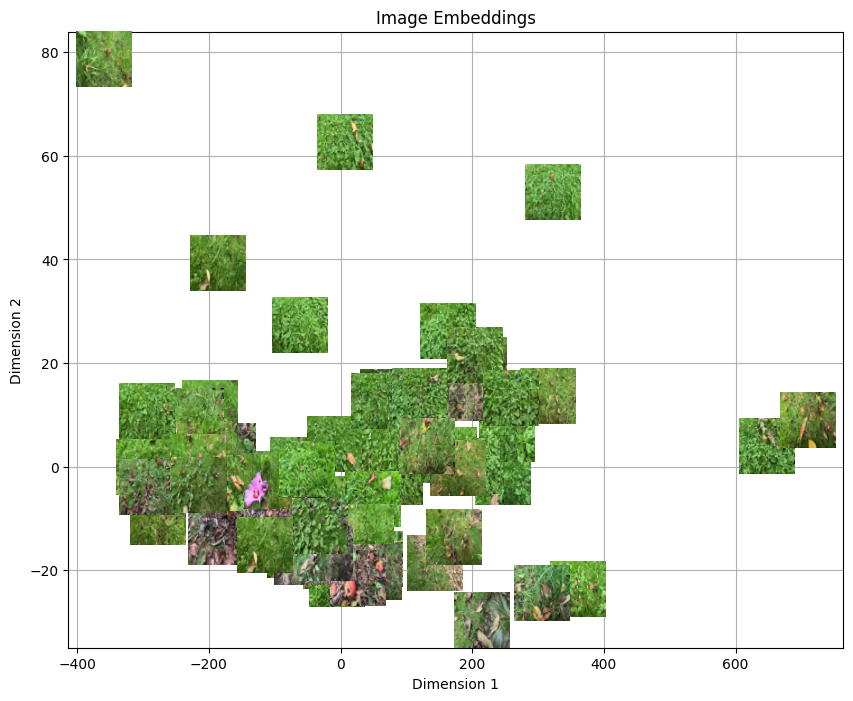

66


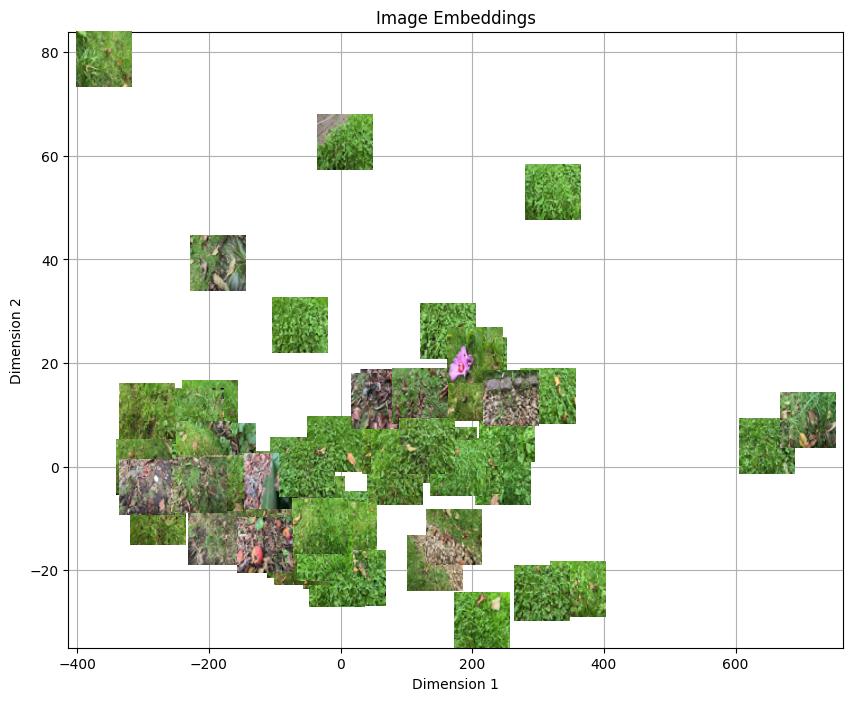

In [11]:
print(len(pca_results))
visualize_embeddings(pca_results)
print(len(first_pruned_embedding))
visualize_embeddings(first_pruned_embedding)
print(len(second_pruned_embedding))
visualize_embeddings(second_pruned_embedding)
print(len(third_pruned_embedding))
visualize_embeddings(third_pruned_embedding)

In [12]:
# # DenseNet model
# model = torch.load("saved_models/DenseNet121_decap.pt", map_location='cpu', weights_only=False)

# json_data_path = "dataset/json_data/model_densenet.json"
# model_json_data = []
# embeddings = []

# for i, frame in enumerate(frames):
#     img = Image.open(frames_path + frame)
#     preprocessed_img = preprocess_image(img)
#     input_tensor = preprocessed_img.unsqueeze(0)
#     features = extract_features(model, input_tensor)

#     data = {
#         "filename": f"frame{i}.jpg",
#         "feature": features.cpu().numpy().flatten().tolist()
#     }
#     model_json_data.append(data)

#     # embeddings.append(features.cpu().numpy().flatten())

# with open(json_data_path, 'w') as json_file:
#     json.dump(model_json_data, json_file, indent=4)

# # embeddings = np.array(embeddings)

In [13]:
# # EfficientNet model
# model = torch.load("saved_models/EfficientNet_b0_decap.pt", map_location='cpu', weights_only=False)

# json_data_path = "dataset/json_data/model_efficientnet.json"
# model_json_data = []
# embeddings = []

# for i, frame in enumerate(frames):
#     img = Image.open(frames_path + frame)
#     preprocessed_img = preprocess_image(img)
#     input_tensor = preprocessed_img.unsqueeze(0)
#     features = extract_features(model, input_tensor)

#     data = {
#         "filename": f"frame{i}.jpg",
#         "feature": features.cpu().numpy().flatten().tolist()
#     }
#     model_json_data.append(data)

#     # embeddings.append(features.cpu().numpy().flatten())

# with open(json_data_path, 'w') as json_file:
#     json.dump(model_json_data, json_file, indent=4)

# # embeddings = np.array(embeddings)